# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias, imputar_info
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11375 entries, 0 to 11374
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11375 non-null  datetime64[ns]
 1   Ticker                       11375 non-null  object        
 2   Close                        11375 non-null  float64       
 3   Open                         11375 non-null  float64       
 4   Volume                       11375 non-null  float64       
 5   DateAdded                    6726 non-null   object        
 6   Sector                       11375 non-null  object        
 7   Industry                     11375 non-null  object        
 8   TotalRevenue                 11375 non-null  float64       
 9   GrossProfit                  10522 non-null  float64       
 10  OperatingIncome              11375 non-null  float64       
 11  NetIncome                    11375 non-nu

## Limpieza de Datos

Limpiar cadenas en Industry y Sector: 
* sin espacios iniciales ni finales.
* primer letra en mayúscula.
* se reemplaza el símbolo '&' por 'And'.

Además se convierten a variables de tipo "Category"

In [3]:
df = limpiar_industry_y_sector(df)

# Ver cambios
df[['Industry', 'Sector']].head()

,Industry,Sector
0,Grocery Stores,Consumer Defensive
1,Semiconductors,Technology
2,Software Infrastructure,Technology
3,Home Improvement Retail,Consumer Cyclical
4,Discount Stores,Consumer Defensive


In [4]:
# Valores únicos en Sector
df['Sector'].value_counts()

Sector
Consumer Cyclical         2330
Industrials               2223
Technology                1834
Healthcare                1140
Financial Services         901
Consumer Defensive         861
Basic Materials            614
Energy                     583
Communication Services     432
Real Estate                251
Utilities                  206
Name: count, dtype: int64

In [5]:
# Valores únicos en Industry
df['Industry'].value_counts()

Industry
Specialty Industrial Machinery           362
Semiconductors                           298
Software Application                     288
Engineering And Construction             263
Information Technology Services          253
                                        ... 
Reit Industrial                           23
Solar                                     22
Luxury Goods                              22
Utilities Independent Power Producers     22
Lumber And Wood Production                21
Name: count, Length: 116, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [6]:
df = columnas_en_millones(df)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [7]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df[(df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                            2149
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                   28.25313
Open                                   31.382216
Volume                                    7.3179
DateAdded                                   None
Sector                               Industrials
Industry                       Metal Fabrication
TotalRevenue                             171.258
GrossProfit                               39.919
OperatingIncome                           32.598
NetIncome                                 25.152
EBITDA                                       NaN
BasicAverageShares                        19.344
CashAndCashEquivalents                   89884.0
CurrentDebt                                  NaN
LongTermDebt                                 NaN
TotalDebt                                    NaN
StockholdersEquity                      302038.0
TotalAssets         

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [8]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df['TotalRevenue'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue  OperatingIncome
517    AVNT 2021-03-01     -30.20000       -12.700000
616     XPO 2021-03-01   -1093.00000        14.000000
750     ALB 2021-03-01   -1790.31392      -114.758843
2266    EMR 2021-12-01    -357.00000      -206.000000
2618   FTNT 2022-03-01   -1415.00000       213.700000
2780    BHF 2022-03-01    -150.00000      2266.000000
2911    XPO 2022-03-01   -2243.00000      -189.000000
4021      J 2022-12-01   -1258.70300       -69.426000
4494    CNA 2023-03-01   -3542.00000     -4648.000000
4782    BAX 2023-03-01    -704.00000      -285.000000
4819    BHF 2023-03-01    -127.00000        40.000000
4870     GE 2023-03-01  -12134.00000      4010.000000
4980    NGL 2023-06-01    -967.05000        65.932000
5816    WDC 2023-09-01   -3391.00000        93.000000
6267      J 2023-12-01   -1212.28200      -120.924000
6290   OTIS 2023-12-01   -3543.00000      -516.000000
6554   NDAQ 2024-03-01    -522.00000       481.000000
6585    DAN 2024-03-01    -4

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observa en 2 casos que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

#### Casos de deuda negativa: 
Se calcula el Pasivo Implícito, que surge de aplicar la ecuación contable fundamental `Activo` = `Pasivo` + `Patrimonio Neto`

In [9]:
# Caso 3:  Deuda negativa
condicion_3 = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)

# Calcular el Pasivo Implícito
df['PasivoImplicito'] = df['TotalAssets'] - df['StockholdersEquity']

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt', 'PasivoImplicito']
anomalias = df.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt  PasivoImplicito
3595    IEP 2022-09-01        NaN     -746.000      7134.000        15991.000
3991    IEP 2022-12-01        NaN     -745.000      7127.000        16908.000
6482   STLD 2024-03-01        NaN      459.987     -3286.537          171.287
7051   STLD 2024-06-01        NaN      425.696     -3570.028         -203.283
8437   STLD 2024-12-01        NaN      882.013     -3997.348         -218.698
8489    TXN 2025-03-01        NaN      750.000    -28049.000       -22289.000
Cantidad de casos: 6


* Se observa que la ecuación contable fundamental no se cumple. 

Se decide eliminar estos registros "tóxicos" del dataset.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos considerando la ecuación `EBITDA` = `OperatingIncome` + `DepreciationAndAmortization`, separando los registros según provengan de `yfinance` o de `simFin`:

In [10]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome', 'FinancialsSource']
anomalias = df.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
11111    GME 2026-06-01                         -0.3   144.9            144.9   

      FinancialsSource  
11111         yfinance  
Cantidad de casos: 1


* En este caso se observa que el valor implicito de `DepreciationAndAmortization` es igual a cero (EBITDA = OperatingIncome).
El valor de -0.3 pudo haberse tratado de un pequeño "ajuste contable", $300.000 dólares para una compañia del tamaño de `GameStop` es contablemente irrelevante. 

Se reemplazará el valor por cero.

In [11]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df['DepreciationAndAmortization'] < 0) & (df['FinancialsSource']=='simFin')

# Ver registros
anomalias = df.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
0        KR 2020-09-01                     -617.000     NaN          820.000   
3       LOW 2020-09-01                     -327.000     NaN         3957.000   
11       DY 2020-09-01                      -44.129     NaN           54.482   
13      TGT 2020-09-01                     -542.000     NaN         2300.000   
15      ADI 2020-09-01                     -107.077     NaN          450.954   
...     ...        ...                          ...     ...              ...   
9662    WGO 2025-09-01                       -5.500     NaN           30.200   
9686    HPE 2025-09-01                      -37.000     NaN          294.000   
9813   AVGO 2025-09-01                     -506.000     NaN         5915.000   
9877   ADBE 2025-09-01                      -41.000     NaN         2109.000   
9906   ORCL 2025-09-01                     -544.000     NaN         5191.000   

     FinancialsSource  
0              

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [12]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df)

# Se elimina la columna calculada 'PasivoImplicito'
df_clean = df_clean.drop(columns= 'PasivoImplicito')

## Tratamiento Inicial de Missings

In [13]:
# Ver incidencia de missings
mostrar_missings(df_clean)

TotalDebt                      0.836485
FreeCashFlow                   0.834638
EBITDA                         0.834638
DepreciationAndAmortization    0.464157
DateAdded                      0.408743
CurrentDebt                    0.236256
GrossProfit                    0.075029
LongTermDebt                   0.056381
TotalNoncurrentLiabilities     0.050664
CurrentAssets                  0.048377
CurrentLiabilities             0.048113
CapitalExpenditure             0.026915
BasicAverageShares             0.004134
CashAndCashEquivalents         0.003958
FinancingCashFlow              0.003254
OperatingCashFlow              0.002639
TotalRevenue                   0.002199
InvestingCashFlow              0.002199
StockholdersEquity             0.001671
TotalLiabilities               0.001407
TotalAssets                    0.001407
NetIncome                      0.000000
Sector                         0.000000
Ticker                         0.000000
OperatingIncome                0.000000


In [14]:
sector_missing = df_clean.loc[df_clean['Sector'].isna(),['Date', 'Close', 'Ticker', 'Sector', 'Industry', 'FinancialsSource']]
print(sector_missing)
print("Cantidad de casos:", len(sector_missing))

Empty DataFrame
Columns: [Date, Close, Ticker, Sector, Industry, FinancialsSource]
Index: []
Cantidad de casos: 0


In [15]:
# Se imputan manualmente los casos encontrados
df_clean = imputar_info(df_clean)

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [16]:
df_fin_imputed = imputar_equivalencias_financieras(df_clean)
mostrar_missings(df_fin_imputed)

DateAdded                      0.408743
GrossProfit                    0.075029
CurrentDebt                    0.039229
LongTermDebt                   0.039229
TotalDebt                      0.039229
CapitalExpenditure             0.026915
FreeCashFlow                   0.025332
BasicAverageShares             0.004134
CashAndCashEquivalents         0.003958
FinancingCashFlow              0.003254
OperatingCashFlow              0.002639
InvestingCashFlow              0.002199
TotalRevenue                   0.002199
StockholdersEquity             0.001671
CurrentLiabilities             0.001407
TotalNoncurrentLiabilities     0.001407
TotalLiabilities               0.001407
CurrentAssets                  0.001407
TotalAssets                    0.001407
NetIncome                      0.000000
EBITDA                         0.000000
Volume                         0.000000
Sector                         0.000000
Date                           0.000000
Ticker                         0.000000


In [17]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_fin_imputed = imputar_numericas(df_fin_imputed)
mostrar_missings(df_fin_imputed)

DateAdded                      0.408743
GrossProfit                    0.066321
CurrentDebt                    0.034128
LongTermDebt                   0.034128
TotalDebt                      0.034128
CapitalExpenditure             0.017328
FreeCashFlow                   0.017152
CashAndCashEquivalents         0.000880
StockholdersEquity             0.000616
CurrentAssets                  0.000616
TotalAssets                    0.000616
CurrentLiabilities             0.000616
TotalLiabilities               0.000616
TotalNoncurrentLiabilities     0.000616
OperatingCashFlow              0.000528
FinancingCashFlow              0.000528
InvestingCashFlow              0.000528
BasicAverageShares             0.000440
TotalRevenue                   0.000000
NetIncome                      0.000000
EBITDA                         0.000000
Volume                         0.000000
Sector                         0.000000
Date                           0.000000
Ticker                         0.000000


Se remueven los Missings remanentes en columnas numéricas relevantes, es decir excluyendo las siguientes columnas que no se utilizan en el pipeline actual:
- `GrossProfit`
- `FinancingCashFlow`
- `InvestingCashFlow`

Es necesario que no hayan valores perdidos antes de calcular los valores TTM. 

In [18]:
cols_no_relevantes = ['GrossProfit', 'FinancingCashFlow', 'InvestingCashFlow']
df_fin_imputed = quitar_nulos_relevantes(df_fin_imputed, cols_no_relevantes)
mostrar_missings(df_fin_imputed)

DateAdded                      0.409833
GrossProfit                    0.055380
Ticker                         0.000000
Close                          0.000000
Open                           0.000000
Volume                         0.000000
Date                           0.000000
Sector                         0.000000
Industry                       0.000000
TotalRevenue                   0.000000
OperatingIncome                0.000000
NetIncome                      0.000000
EBITDA                         0.000000
BasicAverageShares             0.000000
CashAndCashEquivalents         0.000000
CurrentDebt                    0.000000
LongTermDebt                   0.000000
TotalDebt                      0.000000
StockholdersEquity             0.000000
TotalAssets                    0.000000
CurrentAssets                  0.000000
CurrentLiabilities             0.000000
TotalNoncurrentLiabilities     0.000000
TotalLiabilities               0.000000
OperatingCashFlow              0.000000


In [19]:
df_fin_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 1 to 11368
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         10780 non-null  datetime64[ns]
 1   Ticker                       10780 non-null  object        
 2   Close                        10780 non-null  float64       
 3   Open                         10780 non-null  float64       
 4   Volume                       10780 non-null  float64       
 5   DateAdded                    6362 non-null   object        
 6   Sector                       10780 non-null  category      
 7   Industry                     10780 non-null  category      
 8   TotalRevenue                 10780 non-null  float64       
 9   GrossProfit                  10183 non-null  float64       
 10  OperatingIncome              10780 non-null  float64       
 11  NetIncome                    10780 non-null  f

## Feature Engineering

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres):

In [20]:
df_with_features = transformar_flujos_a_ttm(df_fin_imputed)
mostrar_missings(df_with_features)

DateAdded                          0.409833
GrossProfit_TTM                    0.052412
Ticker                             0.000000
Close                              0.000000
Open                               0.000000
Volume                             0.000000
Date                               0.000000
Industry                           0.000000
CashAndCashEquivalents             0.000000
CurrentDebt                        0.000000
LongTermDebt                       0.000000
TotalDebt                          0.000000
StockholdersEquity                 0.000000
TotalAssets                        0.000000
Sector                             0.000000
CurrentAssets                      0.000000
CurrentLiabilities                 0.000000
TotalLiabilities                   0.000000
TotalNoncurrentLiabilities         0.000000
FinancialsSource                   0.000000
TotalRevenue_TTM                   0.000000
OperatingIncome_TTM                0.000000
NetIncome_TTM                   

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [21]:
df_with_features = crear_years_since_added(df_with_features)

* Calcular métricas financieras y ratios de valuación:

In [22]:
df_with_features = calcular_metricas(df_with_features)
mostrar_missings(df_with_features)

DebtToEquity                       0.068182
GrossProfit_TTM                    0.052412
ReturnOnEquity                     0.003618
Ticker                             0.000000
Date                               0.000000
Sector                             0.000000
Industry                           0.000000
CashAndCashEquivalents             0.000000
CurrentDebt                        0.000000
LongTermDebt                       0.000000
Close                              0.000000
Open                               0.000000
Volume                             0.000000
TotalAssets                        0.000000
StockholdersEquity                 0.000000
TotalDebt                          0.000000
CurrentAssets                      0.000000
TotalLiabilities                   0.000000
FinancialsSource                   0.000000
TotalNoncurrentLiabilities         0.000000
CurrentLiabilities                 0.000000
NetIncome_TTM                      0.000000
EBITDA_TTM                      

Convertir `volume`:
* Se reemplaza el volumen total trimestral por su promedio diario (AverageDailyVolume), ya que es el valor estándar utilizado en finanzas. El cálculo es aproximado, dividiendo los valores de `Volume` entre 63 (252 días hábiles entre 4).
* Se aplica lag de 1 período a AverageDailyVolume para evitar Data Leakage.

In [ ]:
df_with_features = convertir_volumen_a_adv(df_with_features)
columnas_lag1 = ['AverageDailyVolume']
df_with_features = calcular_lag(df_with_features, columnas_lag1, q=1)

Cálculo de los crecimientos y las aceleraciones:
* Primero se calculan las tasas de crecimiento para las variables indicadas en "crecimiento_cols", incluyendo las variaciones anuales (YoY) y trimestrales (QoQ) .
* Luego se calculan las aceleraciones (Momento - Tendencia), definidas como la diferencia entre la tasa de cambio de corto plazo (QoQ) y la de largo plazo (YoY). 

In [25]:
# Calcular crecimientos
crecimiento_cols = [
    'TotalRevenue_TTM',
    'EBITDA_TTM',
    'FreeCashFlow_TTM',
    'CapitalExpenditure_TTM',
    'AverageDailyVolume_Lag1'
]
df_with_features = calcular_crecimientos(df_with_features, crecimiento_cols)
df_with_features = calcular_aceleraciones(df_with_features, crecimiento_cols)

* Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker:

In [26]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")

df_with_features = calcular_retornos(df_with_features, df_index)

* Se calculan tamaños relativos: RelativeAssets y RelativeRevenue

In [27]:
df_with_features = calcular_relative_size(df_with_features)
mostrar_missings(df_with_features)

CapitalExpenditure_TTM_Acceleration     0.187570
AverageDailyVolume_Lag1_Acceleration    0.187477
AverageDailyVolume_Lag1_YoY             0.187477
CapitalExpenditure_TTM_YoY              0.187384
TotalRevenue_TTM_Acceleration           0.187106
                                          ...   
BookToMarket                            0.000000
ProfitMargins                           0.000000
OperatingMargins                        0.000000
RelativeAssets                          0.000000
RelativeRevenue                         0.000000
Length: 65, dtype: float64

## Tratamiento Final de Missings

* Se aplica la imputación por medias móviles para las métricas calculadas:

In [ ]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_imputed = imputar_numericas(df_with_features)
df_imputed.info()

AverageDailyVolume_Lag1_YoY             0.187477
AverageDailyVolume_Lag1_Acceleration    0.187477
FreeCashFlow_TTM_Acceleration           0.187106
EBITDA_TTM_Acceleration                 0.187106
CapitalExpenditure_TTM_Acceleration     0.187106
                                          ...   
BookToMarket                            0.000000
ProfitMargins                           0.000000
OperatingMargins                        0.000000
RelativeAssets                          0.000000
RelativeRevenue                         0.000000
Length: 65, dtype: float64

* Se eliminan missings remanentes:

In [30]:
cols_no_relevantes = []
df_imputed = quitar_nulos_relevantes(df_imputed, cols_no_relevantes)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 8 to 10779
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  7814 non-null   datetime64[ns]
 1   Ticker                                7814 non-null   object        
 2   Close                                 7814 non-null   float64       
 3   Open                                  7814 non-null   float64       
 4   Sector                                7814 non-null   category      
 5   Industry                              7814 non-null   category      
 6   CashAndCashEquivalents                7814 non-null   float64       
 7   CurrentDebt                           7814 non-null   float64       
 8   LongTermDebt                          7814 non-null   float64       
 9   TotalDebt                             7814 non-null   float64       
 10  Stoc

## Análisis Exploratorio de Datos

In [31]:
# Distribución de variables contínuas
df_imputed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Date,7814,2024-03-13 00:52:42.324033792,2021-09-01 00:00:00,2022-12-01 00:00:00,2024-03-01 00:00:00,2025-06-01 00:00:00,2026-06-01 00:00:00,NaN
Close,7814.0,1228.2593,0.57,41.9013,84.8785,168.9411,775000.0,25864.5391
Open,7814.0,1189.3718,0.53,41.3552,83.9542,164.7164,775648.0,25004.7888
CashAndCashEquivalents,7814.0,3578.0802,0.1685,309.1928,833.4235,2476.625,546164.0,13571.8282
CurrentDebt,7814.0,1394.874,0.0,68.75,393.3835,1166.475,122798.0,4381.4823
...,...,...,...,...,...,...,...,...
QuarterlyReturn_Lag1,7814.0,0.0289,-0.8019,-0.0762,0.0152,0.1169,3.0547,0.1778
QuarterlyVariance_Lag1,7814.0,0.0318,0.0,0.0071,0.015,0.0302,7.1963,0.1412
MarketCovariance_Lag1,7814.0,0.0022,-0.0832,-0.0003,0.002,0.0046,0.0637,0.0051
RelativeAssets,7814.0,0.0019,0.0,0.0003,0.0007,0.0018,0.0524,0.0038


In [32]:
# Coeficientes de asimetría
df_imputed.select_dtypes(include="number").skew().sort_values(ascending=False)

BookToMarket                            87.145503
NetDebtToEbitda                         53.074346
FcfToEbitda                             50.267932
EarningsYield                           45.145761
TotalRevenue_TTM_QoQ                    40.845022
DebtToEquity                            36.887885
QuarterlyVariance_Lag1                  31.868092
Open                                    24.973331
Close                                   24.953291
CapExToRevenue                          23.171674
EbitdaYield                             21.127352
CashAndCashEquivalents                  17.997661
AverageDailyVolume_Lag1                 16.186155
TotalRevenue_TTM_YoY                    15.260482
CurrentDebt                             12.738996
StockholdersEquity                       8.857207
EBITDA_TTM                               8.824232
MarketCap                                8.798807
EnterpriseValue                          8.724585
TotalDebt                                8.581429


In [33]:
# Analizar extremos
df_min = df_imputed.loc[df_imputed['EnterpriseValue'].idxmin()]
df_min

Date                      2022-03-01 00:00:00
Ticker                                   SNEX
Close                               22.242964
Open                                22.355556
Sector                     Financial Services
                                 ...         
QuarterlyReturn_Lag1                -0.182654
QuarterlyVariance_Lag1               0.029711
MarketCovariance_Lag1                0.006671
RelativeAssets                       0.000976
RelativeRevenue                      0.004453
Name: 8729, Length: 65, dtype: object

Cont


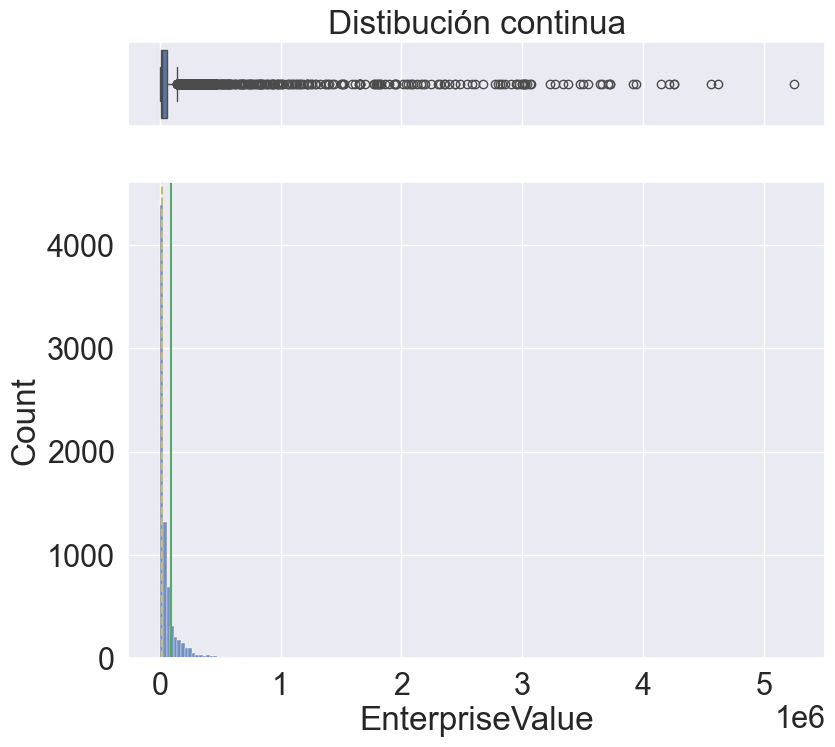

In [34]:
# Graficar
columna_a_graficar = 'EnterpriseValue' # indicar columna para el gráfico
plot(df_imputed[columna_a_graficar])

## Transformaciones

* Transformaciones logarítmicas:

In [35]:
columnas_a_transformar = [ 
    'CapExToRevenue',
    'DebtToEquity',
    'QuarterlyVariance_Lag1',
    'MarketCap',
    'EnterpriseValue'
    ]

df_transformed = transformar_log(
    df_imputed, 
    columnas_a_transformar, 
    calculo_1p=True
    )

# Coeficientes de asimetría actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


BookToMarket                            87.145503
NetDebtToEbitda                         53.074346
FcfToEbitda                             50.267932
EarningsYield                           45.145761
TotalRevenue_TTM_QoQ                    40.845022
Open                                    24.973331
Close                                   24.953291
EbitdaYield                             21.127352
CashAndCashEquivalents                  17.997661
AverageDailyVolume_Lag1                 16.186155
QuarterlyVariance_Lag1_Log1p            15.517430
TotalRevenue_TTM_YoY                    15.260482
CurrentDebt                             12.738996
StockholdersEquity                       8.857207
EBITDA_TTM                               8.824232
TotalDebt                                8.581429
BasicAverageShares_TTM                   8.320628
NetIncome_TTM                            8.304521
OperatingIncome_TTM                      8.000840
FreeCashFlow_TTM                         7.907736


## Tratamiento de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [36]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'EarningsYield',
    'EbitdaYield',
    'BookToMarket',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

In [37]:
df_transformed_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 8 to 10779
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Sector                                7814 non-null   category
 1   Industry                              7814 non-null   category
 2   FinancialsSource                      7814 non-null   object  
 3   YearsSinceAdded                       7814 non-null   float64 
 4   OperatingMargins                      7814 non-null   float64 
 5   ProfitMargins                         7814 non-null   float64 
 6   ReturnOnAssets                        7814 non-null   float64 
 7   ReturnOnEquity                        7814 non-null   float64 
 8   CurrentRatio                          7814 non-null   float64 
 9   NetDebtToEbitda                       7814 non-null   float64 
 10  FcfToEbitda                           7814 non-null   float64 
 11  AverageD

In [38]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [39]:
# Coeficientes de asimetría luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeAssets                          1.732263
AverageDailyVolume_Lag1                 1.724904
QuarterlyVariance_Lag1_Log1p            1.690490
RelativeRevenue                         1.677880
CapExToRevenue_Log1p                    1.636253
CurrentRatio                            1.631766
DebtToEquity_Log1p                      1.568917
YearsSinceAdded                         1.440785
AverageDailyVolume_Lag1_YoY             1.245201
AverageDailyVolume_Lag1_QoQ             1.112753
TotalRevenue_TTM_YoY                    0.954961
FreeCashFlow_TTM_QoQ                    0.734880
EBITDA_TTM_YoY                          0.714149
FreeCashFlow_TTM_YoY                    0.665413
CapitalExpenditure_TTM_Acceleration     0.629687
QuarterlyReturn_Lag1                    0.555255
OperatingMargins                        0.479322
TotalRevenue_TTM_QoQ                    0.471361
ReturnOnEquity                          0.418486
NetDebtToEbitda                         0.372316
EBITDA_TTM_QoQ      

Cont


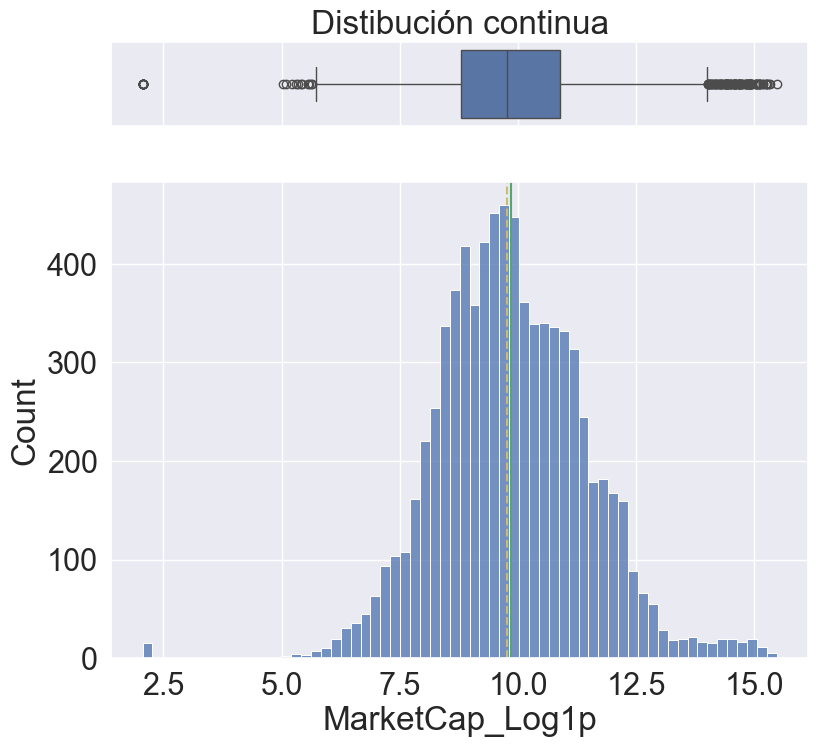

In [40]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [41]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,7814.0,15.136038,20.436722,0.000000e+00,0.000000,7.000000,24.000000,69.000000
OperatingMargins,7814.0,0.141973,0.120307,-3.498320e-01,0.063685,0.124597,0.200976,0.615838
ProfitMargins,7814.0,0.094906,0.112806,-2.982820e-01,0.033517,0.082064,0.144027,0.480588
ReturnOnAssets,7814.0,0.066589,0.071552,-1.855690e-01,0.029056,0.058255,0.099927,0.314485
ReturnOnEquity,7814.0,0.199416,0.267777,-5.762220e-01,0.077176,0.159182,0.292364,0.941371
CurrentRatio,7814.0,1.642115,0.926107,1.314860e-01,1.046371,1.393794,1.982452,4.793313
NetDebtToEbitda,7814.0,3.097643,5.704728,-1.217148e+01,0.631678,2.346451,4.869075,17.612231
FcfToEbitda,7814.0,0.701858,0.904305,-1.534732e+00,0.389627,0.710906,1.029487,2.949749
AverageDailyVolume_Lag1,7814.0,3.319009,4.014471,1.587302e-05,0.708410,1.598610,4.133479,14.447918
TotalRevenue_TTM_YoY,7814.0,0.086686,0.169088,-4.616255e-01,-0.006124,0.064415,0.143781,0.593825


## Concatenación Final y Almacenamiento

In [42]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7814 entries, 8 to 10779
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   CashAndCashEquivalents                7814 non-null   float64       
 1   CurrentDebt                           7814 non-null   float64       
 2   LongTermDebt                          7814 non-null   float64       
 3   TotalDebt                             7814 non-null   float64       
 4   StockholdersEquity                    7814 non-null   float64       
 5   TotalAssets                           7814 non-null   float64       
 6   CurrentAssets                         7814 non-null   float64       
 7   CurrentLiabilities                    7814 non-null   float64       
 8   TotalNoncurrentLiabilities            7814 non-null   float64       
 9   TotalLiabilities                      7814 non-null   float64       
 10  Oper

In [43]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
